### Options Implementation: IV Scalping, Gamma Scalping, and Mean Reversion (Calls & Puts)

---

## 1. Introduction and Environment Setup
* **Importing libraries:** NumPy, Pandas, SciPy, Matplotlib/Seaborn.
* **Loading and cleaning market data:** Underlying asset and options chain prices.
* **Defining Black-Scholes model functions:** Theoretical prices and Greeks for Calls and Puts.

## 2. Underlying Asset Analysis (Volcanic Rock)
* **Return calculation and price distribution analysis**.
* **Stationarity testing and lag autocorrelation calculation:** To detect mean reversion tendencies.
* **Lightweight mean reversion model:** Tracking a fast Exponential Moving Average (EMA) with fixed thresholds.

## 3. Strategy Module: CALL Options
* **3.1. Volatility Smile:** Plotting Implied Volatility (IV) against "Moneyness" ($m_t$) for Call options.
* **3.2. Detrending and Fair IV:** Fitting a parabolic regression to calculate "Fair IV" ($\hat{v}_t$) and isolate implied volatility deviations ($v_t - \hat{v}_t$).
* **3.3. IV Scalping (Calls):** Converting Fair IV into price space using the Black-Scholes model to detect fluctuations and set entry/exit signals.
* **3.4. Signal Analysis:** Evaluating 1-lag negative autocorrelation in Call option returns.
* **3.5. Gamma Scalping (Calls):** Buying Call options with dynamic re-hedging (Delta Hedging) to capitalize on underlying price movements versus time decay (Theta).

## 4. Strategy Module: PUT Options
* **4.1. Volatility Smile:** Adapting IV and Moneyness calculations specifically for Put options.
* **4.2. Detrending and Fair IV:** Parabolic fitting for the Put chain and calculation of noise-free theoretical volatility.
* **4.3. IV Scalping (Puts):** Using the Black-Scholes model for Puts, detecting short-term price deviations when the market overvalues or undervalues the options.
* **4.4. Signal Analysis:** Empirical identification of short-term inefficiencies across Put option strikes.
* **4.5. Gamma Scalping (Puts):** Managing Gamma exposure and hedging the negative Delta of Puts to isolate the value of directional movements.

## 5. Hybrid Strategy and Risk Management
* **5.1. Portfolio Construction:** Dynamically combining the core IV Scalping strategy (Calls and Puts) with a moderate Mean Reversion position.
* **5.2. Drawdown Analysis:** Evaluating the historical volatility of the combined returns.
* **5.3. Risk Metrics:** Calculating 95% Value at Risk (VaR) to limit exposure and maximum losses of the directional (Mean Reversion) strategy.

## 1. Introduction and Environment Setup
* **Importing libraries:** NumPy, Pandas, SciPy, Matplotlib/Seaborn.

In [33]:
# === STANDARD LIBRARY ===
import math
import json
from statistics import NormalDist

_N = NormalDist()
# === DATA MANIPULATION ===
import numpy as np
import pandas as pd

# === VISUALIZACIÓN ===
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# === SCIPY (stats + optimización) ===
from scipy.stats import norm
from scipy.optimize import brentq   # para calcular IV via root-finding
from scipy.stats import  skew, kurtosis
# === PARA EL NOTEBOOK ===
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

**Loading and cleaning market data:** Underlying asset and options chain prices.

In [34]:
# prices and trades use semicolon separator
# observations uses comma separator

# --- prices: order book snapshot every tick, all products ---
prices_day1 = pd.read_csv('prices_round_4_day_1.csv', sep=';')
prices_day2 = pd.read_csv('prices_round_4_day_2.csv', sep=';')
prices_day3 = pd.read_csv('prices_round_4_day_3.csv', sep=';')

# combine all days when available
prices_all = pd.concat([prices_day1, prices_day2, prices_day3], ignore_index=True)

# --- trades: actual market trades that happened ---
trades_day1 = pd.read_csv('trades_round_4_day_1.csv', sep=';')
trades_day2 = pd.read_csv('trades_round_4_day_2.csv', sep=';')
trades_day3 = pd.read_csv('trades_round_4_day_3.csv', sep=';')

trades_all = pd.concat([trades_day1, trades_day2, trades_day3], ignore_index=True)

# --- observations: external data for MAGNIFICENT_MACARONS conversions ---
# note: this file uses comma as separator, not semicolon
obs_day1 = pd.read_csv('observations_round_4_day_1.csv', sep=',')
obs_day2 = pd.read_csv('observations_round_4_day_2.csv', sep=',')
obs_day3 = pd.read_csv('observations_round_4_day_3.csv', sep=',')

obs_all = pd.concat([obs_day1, obs_day2, obs_day3], ignore_index=True)

print(f"prices  shape: {prices_all.shape}")
print(f"trades  shape: {trades_all.shape}")
print(f"obs     shape: {obs_all.shape}")
print(f"\nproducts in prices:\n{sorted(prices_all['product'].unique())}")

prices  shape: (450000, 17)
trades  shape: (54490, 7)
obs     shape: (30000, 8)

products in prices:
['CROISSANTS', 'DJEMBES', 'JAMS', 'KELP', 'MAGNIFICENT_MACARONS', 'PICNIC_BASKET1', 'PICNIC_BASKET2', 'RAINFOREST_RESIN', 'SQUID_INK', 'VOLCANIC_ROCK', 'VOLCANIC_ROCK_VOUCHER_10000', 'VOLCANIC_ROCK_VOUCHER_10250', 'VOLCANIC_ROCK_VOUCHER_10500', 'VOLCANIC_ROCK_VOUCHER_9500', 'VOLCANIC_ROCK_VOUCHER_9750']


**Defining Black-Scholes model functions:** Theoretical prices and Greeks for Calls and Puts.


In [35]:
def _d1_d2(S, K, T, sigma, r=0):
    """
    Compute d1 and d2 — the core inputs to all BS formulas.
    S     : current underlying price
    K     : strike price
    T     : time to expiry in years
    sigma : annualised volatility
    r     : risk-free rate (default 0, reasonable for Prosperity)
    """
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return d1, d2


# ── THEORETICAL PRICES ──────────────────────────────────────

def bs_call_price(S, K, T, sigma, r=0):
    """Black-Scholes price for a European CALL option."""
    d1, d2 = _d1_d2(S, K, T, sigma, r)
    return S * norm.cdf(d1) - K * math.exp(-r * T) * norm.cdf(d2)

def bs_put_price(S, K, T, sigma, r=0):
    """
    Black-Scholes price for a European PUT option.
    Derived from put-call parity: P = C - S + K*e^(-rT)
    """
    d1, d2 = _d1_d2(S, K, T, sigma, r)
    return K * math.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


# ── GREEKS ───────────────────────────────────────────────────

def bs_delta(S, K, T, sigma, option_type='call', r=0):
    """
    Delta — rate of change of option price w.r.t. underlying price.
    Call: delta in [0, 1]   → always positive (you benefit from S rising)
    Put:  delta in [-1, 0]  → always negative (you benefit from S falling)
    """
    d1, _ = _d1_d2(S, K, T, sigma, r)
    if option_type == 'call':
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1

def bs_gamma(S, K, T, sigma, r=0):
    """
    Gamma — rate of change of delta w.r.t. underlying price.
    Identical for calls and puts (by put-call parity).
    High gamma = delta changes fast = position needs frequent rehedging.
    """
    d1, _ = _d1_d2(S, K, T, sigma, r)
    return norm.pdf(d1) / (S * sigma * math.sqrt(T))

def bs_vega(S, K, T, sigma, r=0):
    """
    Vega — sensitivity of option price to a change in volatility.
    Identical for calls and puts.
    High vega = price is very sensitive to IV changes.
    """
    d1, _ = _d1_d2(S, K, T, sigma, r)
    return S * norm.pdf(d1) * math.sqrt(T)

def bs_theta(S, K, T, sigma, option_type='call', r=0):
    """
    Theta — rate of change of option price w.r.t. time (time decay).
    Usually negative: options lose value as expiry approaches.
    Put theta can be positive for deep ITM puts (rare but possible).
    """
    d1, d2 = _d1_d2(S, K, T, sigma, r)
    decay = -(S * norm.pdf(d1) * sigma) / (2 * math.sqrt(T))
    if option_type == 'call':
        return decay - r * K * math.exp(-r * T) * norm.cdf(d2)
    else:
        return decay + r * K * math.exp(-r * T) * norm.cdf(-d2)

def bs_rho(S, K, T, sigma, option_type='call', r=0):
    """
    Rho — sensitivity to the risk-free rate.
    Less relevant in Prosperity since r=0, included for completeness.
    Call rho > 0  (higher rates → call worth more)
    Put  rho < 0  (higher rates → put worth less)
    """
    _, d2 = _d1_d2(S, K, T, sigma, r)
    if option_type == 'call':
        return K * T * math.exp(-r * T) * norm.cdf(d2)
    else:
        return -K * T * math.exp(-r * T) * norm.cdf(-d2)
# ── CONVENIENCE WRAPPER ──────────────────────────────────────

def bs_all(S, K, T, sigma, option_type='call', r=0):
    """
    Returns all BS outputs in one dict.
    Useful for building a DataFrame row by row.
    """
    price_fn = bs_call_price if option_type == 'call' else bs_put_price
    return {
        'price' : price_fn(S, K, T, sigma, r),
        'delta' : bs_delta(S, K, T, sigma, option_type, r),
        'gamma' : bs_gamma(S, K, T, sigma, r),
        'vega'  : bs_vega(S, K, T, sigma, r),
        'theta' : bs_theta(S, K, T, sigma, option_type, r),
        'rho'   : bs_rho(S, K, T, sigma, option_type, r),
    }


## 2. Underlying Asset Analysis (Volcanic Rock)
* **Return calculation and price distribution analysis**.

In [6]:
# VOLCANIC_ROCK_VOUCHER_XXXX are call options on VOLCANIC_ROCK.
# The number at the end is the strike price.
#
# For put options: if Prosperity ever introduces them, 
# the data loading would be identical — just filter by the 
# put symbol name instead. You could also derive synthetic put 
# prices from calls via put-call parity: P = C - S + K
# (assuming r=0, which is reasonable here since there are no risk-free rates)
# ============================================================

UNDERLYING = 'VOLCANIC_ROCK'
CALL_STRIKES = [9500, 9750, 10000, 10250, 10500]
CALL_SYMBOLS = [f'VOLCANIC_ROCK_VOUCHER_{k}' for k in CALL_STRIKES]

# underlying price series: one mid_price per timestamp
underlying = (
    prices_all[prices_all['product'] == UNDERLYING]
    [['day', 'timestamp', 'mid_price', 'bid_price_1', 'ask_price_1']]
    .rename(columns={'mid_price': 'S'})
    .reset_index(drop=True)
)

# call options: mid_price per timestamp and strike
calls = (
    prices_all[prices_all['product'].isin(CALL_SYMBOLS)]
    [['day', 'timestamp', 'product', 'mid_price', 'bid_price_1', 'ask_price_1']]
    .assign(strike=lambda df: df['product'].str.extract(r'(\d+)$').astype(int))
    .drop(columns='product')
    .reset_index(drop=True)
)

# trades for the underlying and options only
option_trades = trades_all[
    trades_all['symbol'].isin([UNDERLYING] + CALL_SYMBOLS)
].reset_index(drop=True)


In [10]:
vr = (
    prices_all[prices_all['product'] == 'VOLCANIC_ROCK']
    .reset_index(drop=True)
)
# Log returns: ln(S_t / S_{t-1})
# More useful than simple returns for option pricing (BS assumes log-normal)
vr['log_return'] = np.log(vr['mid_price'] / vr['mid_price'].shift(1))

# Simple returns for reference
vr['simple_return'] = vr['mid_price'].pct_change()

# Drop the first NaN row
returns = vr['log_return'].dropna()

print("=== Return statistics ===")
print(f"  Mean      : {returns.mean():.6f}")
print(f"  Std       : {returns.std():.6f}")
print(f"  Skewness  : {skew(returns):.4f}")
print(f"  Kurtosis  : {kurtosis(returns):.4f}  (excess, normal=0)")
print(f"  Min       : {returns.min():.6f}")
print(f"  Max       : {returns.max():.6f}")

=== Return statistics ===
  Mean      : -0.000002
  Std       : 0.000239
  Skewness  : -1.0334
  Kurtosis  : 29.8913  (excess, normal=0)
  Min       : -0.006772
  Max       : 0.003306


In [14]:
# SPREAD (BID-ASK)
#
# Spread = ask_price_1 - bid_price_1  (best bid and best ask)
# Relative spread normalises by mid_price for comparability
# ============================================================

vr['spread']          = vr['ask_price_1'] - vr['bid_price_1']
vr['spread_relative'] = vr['spread'] / vr['mid_price']
vr['mid_vs_mean']     = vr['mid_price'] - vr['mid_price'].mean()

print("=== Spread statistics ===")
print(f"  Mean spread          : {vr['spread'].mean():.4f}")
print(f"  Median spread        : {vr['spread'].median():.4f}")
print(f"  Mean relative spread : {vr['spread_relative'].mean():.6f}")

=== Spread statistics ===
  Mean spread          : 1.4853
  Median spread        : 1.0000
  Mean relative spread : 0.000145


In [12]:
# ============================================================
#ORDER BOOK IMBALANCE (BID vs ASK)
#
# Imbalance = (total_bid_vol - total_ask_vol) / (total_bid_vol + total_ask_vol)
# Range [-1, +1]:
#   +1  → all volume on bid side  → buying pressure
#   -1  → all volume on ask side  → selling pressure
#    0  → balanced book
#
# We use level 1 (always present) and add levels 2 and 3 where available
# ============================================================

# Total volume per side across all available levels
vr['total_bid_vol'] = vr['bid_volume_1'].fillna(0) + \
                      vr['bid_volume_2'].fillna(0) + \
                      vr['bid_volume_3'].fillna(0)

vr['total_ask_vol'] = vr['ask_volume_1'].fillna(0) + \
                      vr['ask_volume_2'].fillna(0) + \
                      vr['ask_volume_3'].fillna(0)

vr['imbalance'] = (
    (vr['total_bid_vol'] - vr['total_ask_vol']) /
    (vr['total_bid_vol'] + vr['total_ask_vol'])
)

print("=== Imbalance statistics ===")
print(f"  Mean     : {vr['imbalance'].mean():.4f}")
print(f"  Std      : {vr['imbalance'].std():.4f}")
print(f"  % positive (buy pressure)  : {(vr['imbalance'] > 0).mean()*100:.1f}%")
print(f"  % negative (sell pressure) : {(vr['imbalance'] < 0).mean()*100:.1f}%")

=== Imbalance statistics ===
  Mean     : 0.0000
  Std      : 0.0068
  % positive (buy pressure)  : 5.8%
  % negative (sell pressure) : 5.7%


In [15]:
# ============================================================
#     VOLUME PER LEVEL (bid and ask separately)
#
# Shows how deep the book is and where most volume sits
# ============================================================

level_stats = pd.DataFrame({
    'bid_vol_mean' : [vr['bid_volume_1'].mean(),
                      vr['bid_volume_2'].mean(),
                      vr['bid_volume_3'].mean()],
    'ask_vol_mean' : [vr['ask_volume_1'].mean(),
                      vr['ask_volume_2'].mean(),
                      vr['ask_volume_3'].mean()],
    'bid_presence' : [vr['bid_volume_1'].notna().mean(),
                      vr['bid_volume_2'].notna().mean(),
                      vr['bid_volume_3'].notna().mean()],
    'ask_presence' : [vr['ask_volume_1'].notna().mean(),
                      vr['ask_volume_2'].notna().mean(),
                      vr['ask_volume_3'].notna().mean()],
}, index=['level_1', 'level_2', 'level_3'])

print("=== Volume per book level ===")
print(level_stats.round(3))

=== Volume per book level ===
         bid_vol_mean  ask_vol_mean  bid_presence  ask_presence
level_1       136.295       137.579         1.000         1.000
level_2        62.118        60.997         0.779         0.763
level_3        60.894        59.418         0.003         0.013


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


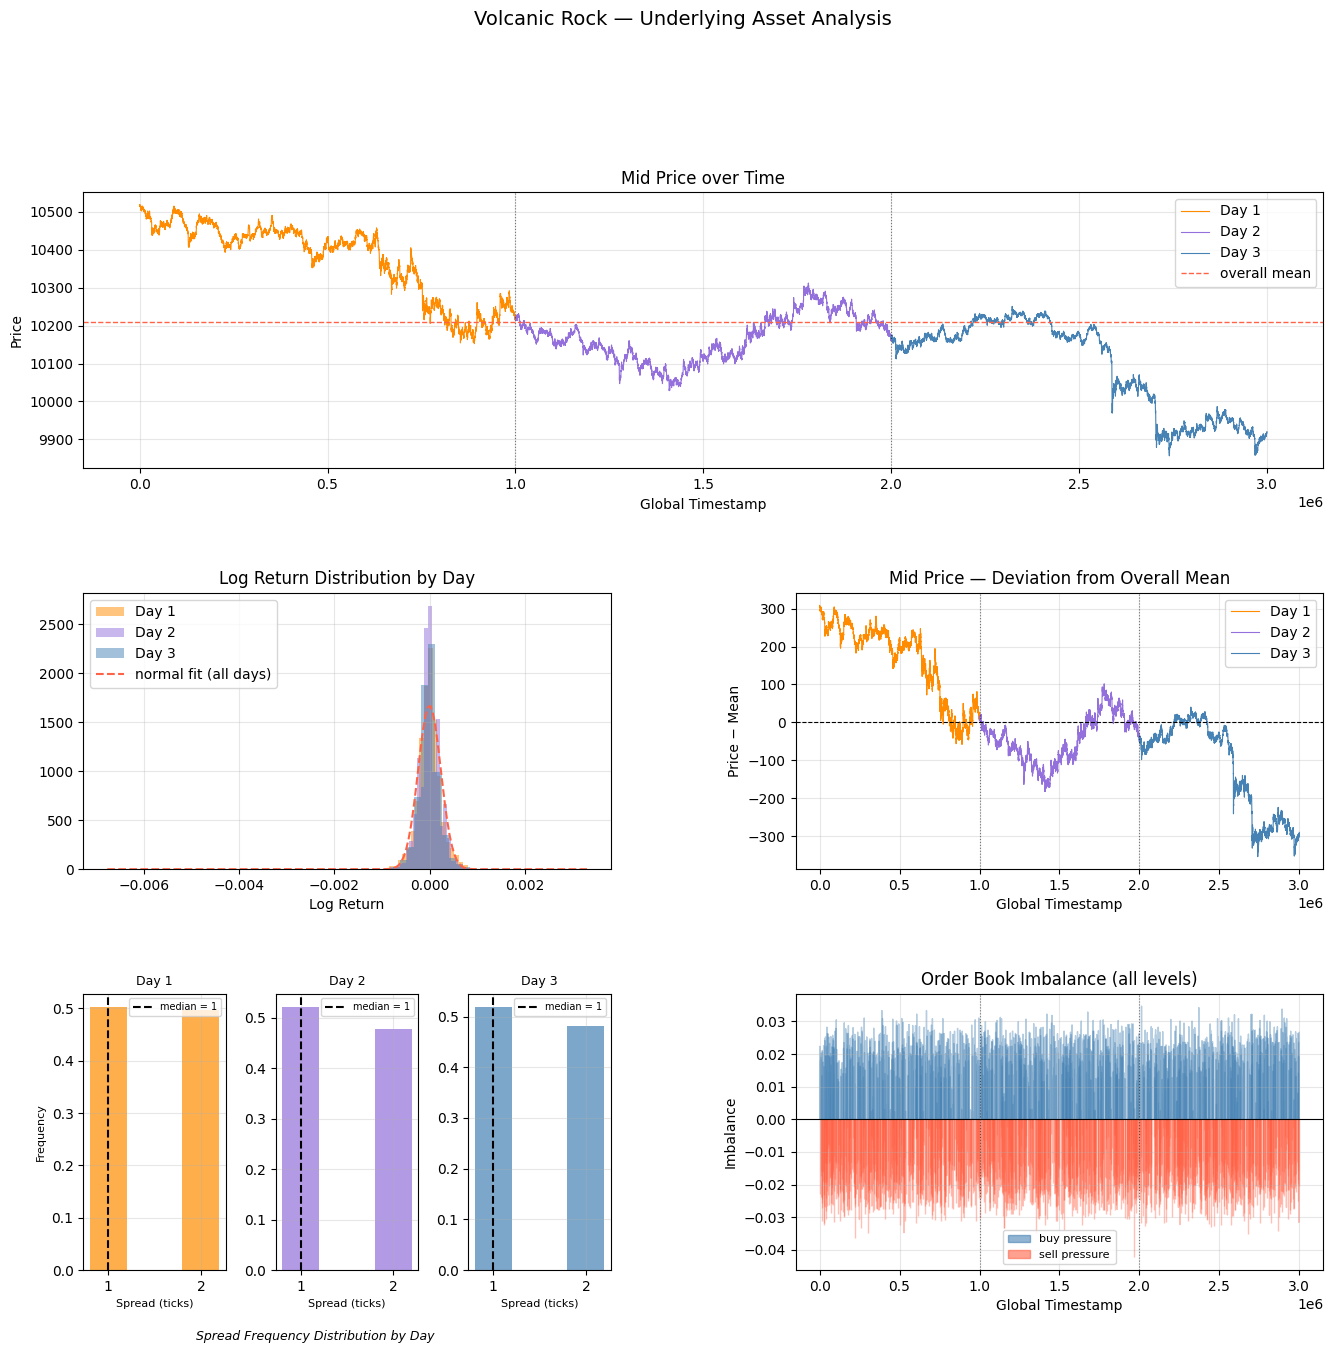

In [19]:
# ============================================================
# 2.5 — PLOTS (3 days aware)
#
# Each day resets timestamp to 0, so we build a global_timestamp
# to plot all days on a continuous x-axis without overlapping.
# Each day is also colored differently so you can see the separation.
# ============================================================

TICKS_PER_DAY = 1_000_000  # timestamp resets every day, max is 999900

# Global timestamp: day offset + within-day timestamp
vr['global_ts'] = (vr['day'] - vr['day'].min()) * TICKS_PER_DAY + vr['timestamp']

DAY_COLORS = {0: 'steelblue', 1: 'darkorange', 2: 'mediumpurple'}
days = sorted(vr['day'].unique())

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- (A) Mid price over time — one color per day ---
ax0 = fig.add_subplot(gs[0, :])
for d in days:
    mask = vr['day'] == d
    ax0.plot(vr.loc[mask, 'global_ts'], vr.loc[mask, 'mid_price'],
             lw=0.8, color=DAY_COLORS[d % 3], label=f'Day {d}')
ax0.axhline(vr['mid_price'].mean(), color='tomato', ls='--', lw=1, label='overall mean')
# vertical lines to mark day boundaries
for d in days[1:]:
    ax0.axvline((d - vr['day'].min()) * TICKS_PER_DAY,
                color='black', ls=':', lw=0.8, alpha=0.5)
ax0.set_title('Mid Price over Time')
ax0.set_xlabel('Global Timestamp')
ax0.set_ylabel('Price')
ax0.legend()
ax0.grid(alpha=0.3)

# --- (B) Log return distribution vs Normal — one curve per day ---
ax1 = fig.add_subplot(gs[1, 0])
for d in days:
    r_day = vr.loc[vr['day'] == d, 'log_return'].dropna()
    ax1.hist(r_day, bins=60, density=True,
             color=DAY_COLORS[d % 3], alpha=0.5, label=f'Day {d}')
# normal fit over all days combined
x = np.linspace(returns.min(), returns.max(), 200)
ax1.plot(x, norm.pdf(x, returns.mean(), returns.std()),
         color='tomato', lw=1.5, ls='--', label='normal fit (all days)')
ax1.set_title('Log Return Distribution by Day')
ax1.set_xlabel('Log Return')
ax1.legend()
ax1.grid(alpha=0.3)

# --- (C) Mid price deviation from overall mean — one color per day ---
ax2 = fig.add_subplot(gs[1, 1])
overall_mean = vr['mid_price'].mean()
for d in days:
    mask = vr['day'] == d
    ax2.plot(vr.loc[mask, 'global_ts'],
             vr.loc[mask, 'mid_price'] - overall_mean,
             lw=0.8, color=DAY_COLORS[d % 3], label=f'Day {d}')
ax2.axhline(0, color='black', lw=0.8, ls='--')
for d in days[1:]:
    ax2.axvline((d - vr['day'].min()) * TICKS_PER_DAY,
                color='black', ls=':', lw=0.8, alpha=0.5)
ax2.set_title('Mid Price — Deviation from Overall Mean')
ax2.set_xlabel('Global Timestamp')
ax2.set_ylabel('Price − Mean')
ax2.legend()
ax2.grid(alpha=0.3)

# --- (D) Spread frequency distribution — one subplot per day ---
gs_d = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[2, 0], wspace=0.35)

for i, d in enumerate(days):
    ax = fig.add_subplot(gs_d[i])
    s_day      = vr.loc[vr['day'] == d, 'spread'].dropna().astype(int)
    median_val = s_day.median()
    counts     = s_day.value_counts().sort_index()

    ax.bar(counts.index, counts / len(s_day),
           color=DAY_COLORS[d % 3], alpha=0.7, width=0.4)
    ax.axvline(median_val, color='black', ls='--', lw=1.5,
               label=f'median = {median_val:.0f}')
    ax.set_title(f'Day {d}', fontsize=9)
    ax.set_xlabel('Spread (ticks)', fontsize=8)
    if i == 0:
        ax.set_ylabel('Frequency', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xticks(counts.index)

# add a shared title for the 3 subplots
fig.text(
    0.27, 0.06,                  # adjust x,y if it overlaps
    'Spread Frequency Distribution by Day',
    ha='center', fontsize=9, style='italic'
)

# --- (E) Order book imbalance — one color per day ---
ax4 = fig.add_subplot(gs[2, 1])
for d in days:
    mask = vr['day'] == d
    ts  = vr.loc[mask, 'global_ts']
    imb = vr.loc[mask, 'imbalance']
    ax4.fill_between(ts, imb, where=imb >= 0,
                     color='steelblue', alpha=0.4)
    ax4.fill_between(ts, imb, where=imb < 0,
                     color='tomato', alpha=0.4)
    # invisible line just for the day legend
    ax4.plot(ts, imb, lw=0, color=DAY_COLORS[d % 3],
             label=f'Day {d}')
for d in days[1:]:
    ax4.axvline((d - vr['day'].min()) * TICKS_PER_DAY,
                color='black', ls=':', lw=0.8, alpha=0.5)
ax4.axhline(0, color='black', lw=0.8)
ax4.set_title('Order Book Imbalance (all levels)')
ax4.set_xlabel('Global Timestamp')
ax4.set_ylabel('Imbalance')

# manual legend for imbalance colors
from matplotlib.patches import Patch
ax4.legend(handles=[
    Patch(color='steelblue', alpha=0.6, label='buy pressure'),
    Patch(color='tomato',    alpha=0.6, label='sell pressure'),
], fontsize=8)
ax4.grid(alpha=0.3)

plt.suptitle('Volcanic Rock — Underlying Asset Analysis', fontsize=14, y=1.01)
plt.show()

* **Stationarity testing and lag autocorrelation calculation:** To detect mean reversion tendencies.

In [22]:
from statsmodels.tsa.stattools import adfuller, acf, pacf

# We test on mid_price (levels) and on log_returns separately.
# A stationary series has a stable mean and variance over time
# — a prerequisite for mean-reversion strategies.
# ============================================================
#AUGMENTED DICKEY-FULLER TEST (ADF)
#
# H0: the series has a unit root → NOT stationary (random walk)
# H1: the series is stationary
#
# If p-value < 0.05 we reject H0 → series is stationary
# A stationary price series suggests mean reversion is exploitable
# ============================================================

def adf_report(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"  ADF statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.6f}")
    print(f"  Lags used     : {result[2]}")
    print(f"  Critical values:")
    for level, val in result[4].items():
        print(f"    {level} : {val:.4f}")
    conclusion = "STATIONARY ✓" if result[1] < 0.05 else "NON-STATIONARY ✗"
    print(f"  → {conclusion}  (p {'<' if result[1] < 0.05 else '>'} 0.05)\n")

print("=== ADF — Mid Price (levels) ===")
adf_report(vr['mid_price'], 'mid_price')

print("=== ADF — Log Returns ===")
adf_report(vr['log_return'], 'log_return')
"""
**1. Mid Price (Levels) = The "Position" (Non-Stationary)**
This is the absolute price of the asset. It moves like a "random walk," meaning it wanders unpredictably and has no natural,
 constant average to return to over time.

**2. Log Returns = The "Step Size" (Stationary)**
This is the period-to-period percentage change. Even if the price itself wanders far away,
 the *size* of the steps it takes remains stable, clustering reliably around a constant average (usually near zero). 
 Because of this stable behavior, mathematical models require returns, not prices, to work properly.
 """

=== ADF — Mid Price (levels) ===
  ADF statistic : -1.2627
  p-value       : 0.646067
  Lags used     : 50
  Critical values:
    1% : -3.4306
    5% : -2.8616
    10% : -2.5668
  → NON-STATIONARY ✗  (p > 0.05)

=== ADF — Log Returns ===
  ADF statistic : -26.1914
  p-value       : 0.000000
  Lags used     : 49
  Critical values:
    1% : -3.4306
    5% : -2.8616
    10% : -2.5668
  → STATIONARY ✓  (p < 0.05)



'\n**1. Mid Price (Levels) = The "Position" (Non-Stationary)**\nThis is the absolute price of the asset. It moves like a "random walk," meaning it wanders unpredictably and has no natural,\n constant average to return to over time.\n\n**2. Log Returns = The "Step Size" (Stationary)**\nThis is the period-to-period percentage change. Even if the price itself wanders far away,\n the *size* of the steps it takes remains stable, clustering reliably around a constant average (usually near zero). \n Because of this stable behavior, mathematical models require returns, not prices, to work properly.\n '

In [23]:
# ============================================================
#   ACF AND PACF
#
# ACF  (Autocorrelation Function):
#   correlation between the series and its own lagged values
#   significant at lag k → price k steps ago still influences today
#
# PACF (Partial ACF):
#   same but removes the effect of intermediate lags
#   useful to identify the direct lag order for a model
#
# For mean reversion: we expect negative ACF at small lags
# (price tends to reverse after moving in one direction)
# ============================================================

N_LAGS = 50

acf_price   = acf(vr['mid_price'].dropna(),  nlags=N_LAGS, fft=True)
pacf_price  = pacf(vr['mid_price'].dropna(), nlags=N_LAGS)

acf_ret     = acf(vr['log_return'].dropna(),  nlags=N_LAGS, fft=True)
pacf_ret    = pacf(vr['log_return'].dropna(), nlags=N_LAGS)

# 95% confidence band: ± 1.96 / sqrt(n)
n       = vr['mid_price'].dropna().shape[0]
conf_95 = 1.96 / np.sqrt(n)

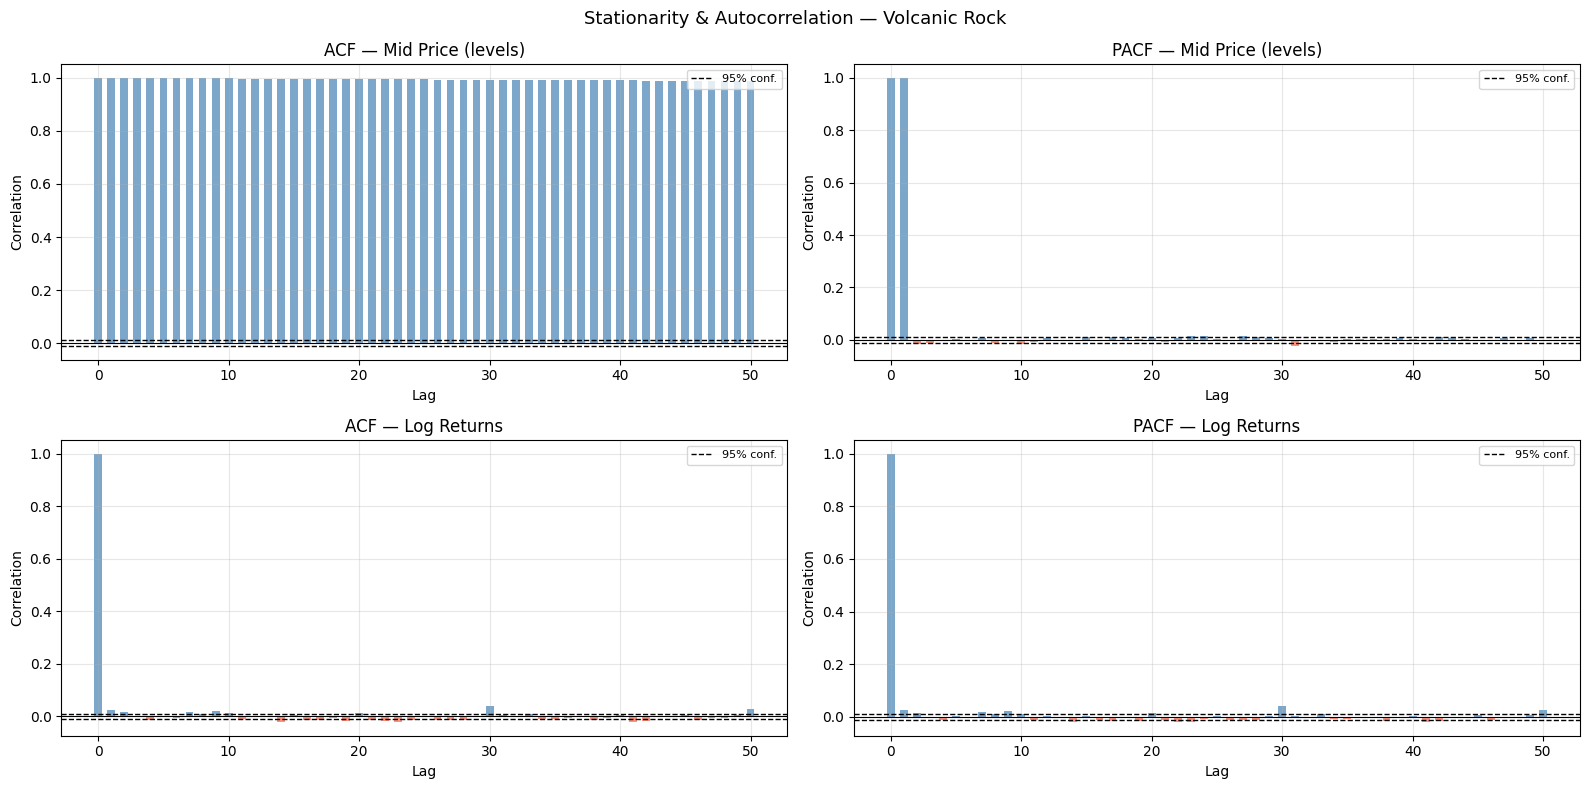

In [24]:
# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
lags = np.arange(N_LAGS + 1)

titles = [
    ('ACF — Mid Price (levels)',   acf_price),
    ('PACF — Mid Price (levels)',  pacf_price),
    ('ACF — Log Returns',          acf_ret),
    ('PACF — Log Returns',         pacf_ret),
]

for ax, (title, values) in zip(axes.flat, titles):
    # bar plot for each lag
    colors = ['tomato' if v < 0 else 'steelblue' for v in values]
    ax.bar(lags, values, color=colors, alpha=0.7, width=0.6)

    # 95% confidence bands
    ax.axhline( conf_95, color='black', ls='--', lw=1, label='95% conf.')
    ax.axhline(-conf_95, color='black', ls='--', lw=1)
    ax.axhline(0, color='black', lw=0.8)

    ax.set_title(title)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Correlation')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Stationarity & Autocorrelation — Volcanic Rock', fontsize=13)
plt.tight_layout()
plt.show()


## Interpretation Guide — ADF, ACF, PACF

### ADF Test
| Result | Meaning | Action |
|---|---|---|
| p < 0.05 | **Stationary** | Price mean-reverts → level is directly tradeable |
| p > 0.05 | **Non-stationary** | Random walk → trade the returns, not the level |

---

### ACF — Price Levels
| Pattern | Meaning |
|---|---|
| All bars ≈ 1.0, slow decay | Non-stationary, random walk |
| Bars drop to 0 after lag k | Stationary, MA(k) structure |
| Negative bars at small lags | Mean reversion present |

### PACF — Price Levels
| Pattern | Meaning |
|---|---|
| Only lag 1 significant | AR(1) → EMA window of 1 tick is enough |
| Significant up to lag k | AR(k) → use a wider EMA window |
| Nothing beyond lag 0 | No autoregressive structure |

---

### ACF / PACF — Log Returns
| Pattern | Meaning |
|---|---|
| All bars inside dashed bands | No memory, no momentum to exploit |
| Positive bar at lag k | Momentum: up tends to follow up |
| Negative bar at lag k | Reversal: up tends to be followed by down |
| Bars outside bands at many lags | Volatility clustering likely |

* **Lightweight mean reversion model:** Tracking a fast Exponential Moving Average (EMA) with fixed thresholds.

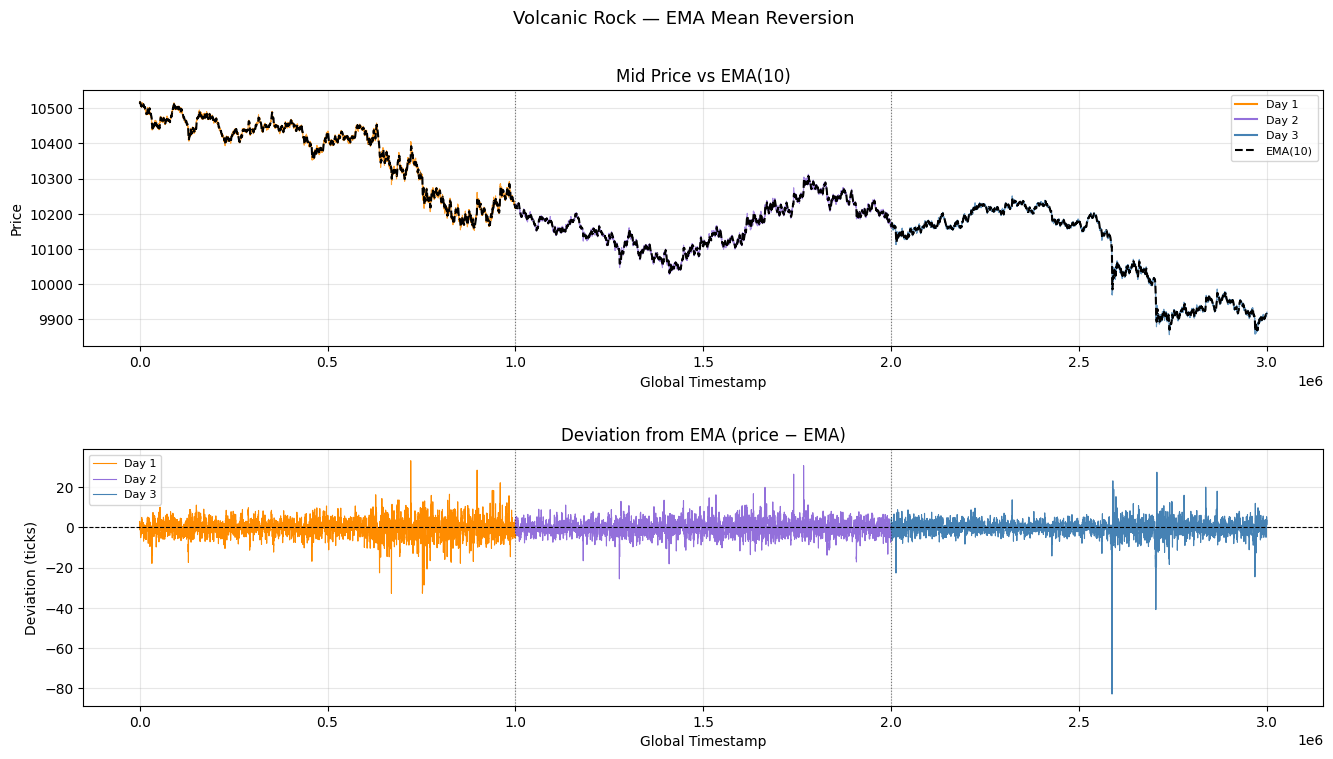

In [28]:
# ============================================================
#    EMA CALIBRATION FROM ADF + ACF/PACF RESULTS
#
# HOW TO CHOOSE THE EMA WINDOW:
#
# 1. ADF on price levels
#    p < 0.05 (stationary)     → price reverts to a stable mean
#                                 use a LONGER window (20-50)
#    p > 0.05 (non-stationary) → price drifts, no stable mean
#                                 use a SHORTER window (5-15)
#
# 2. PACF on price levels
#    significant up to lag k   → set EMA window ≈ k
#    only lag 1 significant    → AR(1), window = 5-10 is enough
#    nothing significant       → no autoregressive structure
#
# 3. ACF on log returns
#    all bars inside bands     → no momentum, mean reversion is right
#    positive bars at lag k    → momentum present, use LONGER window
#    negative bars at lag k    → fast reversal, use SHORTER window
#
# OUR CASE:
#   ADF  p > 0.05  → non-stationary → short window
#   PACF → only lag 1 significant   → AR(1)    → window = 10
#   ACF returns → all inside bands  → no momentum confirmed
#   → EMA_WINDOW = 10
# ============================================================

from matplotlib.lines import Line2D

EMA_WINDOW    = 10
TICKS_PER_DAY = 1_000_000

# EMA computed per day — resets at the start of each day
# so state does not carry over from the previous day
vr['ema'] = (
    vr.groupby('day')['mid_price']
    .transform(lambda s: s.ewm(span=EMA_WINDOW, adjust=False).mean())
)
vr['deviation'] = vr['mid_price'] - vr['ema']

# global timestamp for continuous x-axis across days
vr['global_ts'] = (vr['day'] - vr['day'].min()) * TICKS_PER_DAY + vr['timestamp']

days = sorted(vr['day'].unique())

# --- plot ---
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'hspace': 0.4})

for d in days:
    mask  = vr['day'] == d
    color = DAY_COLORS[d % 3]

    # price — colored per day
    axes[0].plot(vr.loc[mask, 'global_ts'], vr.loc[mask, 'mid_price'],
                 lw=0.8, color=color, alpha=0.8, label=f'Day {d}')
    # EMA — always black so it stands out against the price line
    axes[0].plot(vr.loc[mask, 'global_ts'], vr.loc[mask, 'ema'],
                 lw=1.5, color='black', ls='--')

    # deviation
    axes[1].plot(vr.loc[mask, 'global_ts'], vr.loc[mask, 'deviation'],
                 lw=0.8, color=color, label=f'Day {d}')

# day boundary lines
for d in days[1:]:
    boundary = (d - vr['day'].min()) * TICKS_PER_DAY
    axes[0].axvline(boundary, color='black', ls=':', lw=0.8, alpha=0.5)
    axes[1].axvline(boundary, color='black', ls=':', lw=0.8, alpha=0.5)

# legend with explicit EMA entry
axes[0].legend(
    handles=[
        *[Line2D([0],[0], color=DAY_COLORS[d % 3], lw=1.5, label=f'Day {d}') for d in days],
        Line2D([0],[0], color='black', lw=1.5, ls='--', label=f'EMA({EMA_WINDOW})')
    ],
    fontsize=8
)
axes[0].set_title(f'Mid Price vs EMA({EMA_WINDOW})')
axes[0].set_xlabel('Global Timestamp')
axes[0].set_ylabel('Price')
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title('Deviation from EMA (price − EMA)')
axes[1].set_xlabel('Global Timestamp')
axes[1].set_ylabel('Deviation (ticks)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Volcanic Rock — EMA Mean Reversion', fontsize=13)
plt.show()

## 3. Strategy Module: CALL Options
* **3.1. Volatility Smile:** Plotting Implied Volatility (IV) against "Moneyness" ($m_t$) for Call options.



The vol smile plots Implied Volatility (IV) against moneyness.

### Moneyness ($m_t$)

$$m_t = \frac{\ln(K / S)}{\sqrt{T}}$$

* **$m_t = 0$** $\rightarrow$ At The Money (ATM), $K = S$
* **$m_t > 0$** $\rightarrow$ Out of The Money (OTM call), $K > S$
* **$m_t < 0$** $\rightarrow$ In The Money (ITM call), $K < S$

*Note: Dividing by $\sqrt{T}$ normalises across different Time To Expirations (TTEs), ensuring that smiles from different timestamps remain comparable.*

### What to Look For

* **Flat Smile:** The market prices all strikes with the same volatility (theoretical Black-Scholes world).
* **Skew:** OTM puts and ITM calls are priced with higher volatility than ATM options.
* **Smirk / Smile:** A U-shape where both wings have higher volatility than ATM options.

> **Trading Insight:** If the volatility smile is stable across time, you can fit a curve to it and exploit relative mispricings.

In [70]:
# ============================================================
# TTE Formula (Simplified and Corrected)
# TTE = (8 - GLOBAL_DAY - DAY_FRACTION) / 365
# ============================================================

DAYS_PER_YEAR = 365

def get_tte(csv_day, timestamp, global_day_offset=3):
    """
    Calcula el Time To Expiry (T).
    
    :param csv_day: El día que sale en tu dataframe (1, 2, 3).
    :param timestamp: El timestamp actual (0 a 1,000,000).
    :param global_day_offset: Ajuste para convertir el csv_day al "Día Global" de la competición.
                              Si estás analizando datos de la Ronda 4, y sus días son el 4, 5 y 6 
                              de la competición en total, el offset dependerá de cómo vengan tus datos.
                              *Asegúrate de ajustar este offset para que el global_day tenga sentido (ej: 4, 5, 6)*.
    """
    # 1. Convertir el día del CSV al Día Global de la competición
    # (Asumiendo que Round 4 empieza en el día 4 global. Ajusta si es diferente)
    global_day = csv_day + global_day_offset 
    
    # 2. Calcular qué fracción del día actual ya ha pasado (0.0 al inicio, 1.0 al final)
    day_fraction = (timestamp // 100) / 10000.0
    
    # 3. Calcular TTE usando la fórmula simplificada
    tte = (8 - global_day - day_fraction) / DAYS_PER_YEAR
    
    return tte


# ============================================================
# IMPLIED VOLATILITY ROOT FINDER
# ============================================================
def implied_vol(market_price, S, K, T, option_type='call', r=0):
    """
    Implied volatility via Brent root-finding.
    Asks: what sigma makes the BS price match the market price?
    Returns None if it fails to converge.
    """
    pricer = bs_call_price if option_type == 'call' else bs_put_price
    try:
        return brentq(
            lambda sigma: pricer(S, K, T, sigma, r) - market_price,
            1e-6, 10.0, xtol=1e-8
        )
    except (ValueError, RuntimeError):
        return None
# ============================================================
# BUILD MERGED DATAFRAME: calls + underlying at each timestamp
# ============================================================

underlying = (
    prices_all[prices_all['product'] == 'VOLCANIC_ROCK']
    [['day', 'timestamp', 'mid_price']]
    .rename(columns={'mid_price': 'S'})
)

calls = (
    prices_all[prices_all['product'].isin(CALL_SYMBOLS)]
    [['day', 'timestamp', 'product', 'mid_price']]
    .assign(strike=lambda df: df['product'].str.extract(r'(\d+)$').astype(int))
    .drop(columns='product')
    .rename(columns={'mid_price': 'call_price'})
)

merged = calls.merge(underlying, on=['day', 'timestamp'])
merged['T']         = merged.apply(lambda r: get_tte(r['day'], r['timestamp']), axis=1)
merged['moneyness'] = np.log(merged['strike'] / merged['S']) / np.sqrt(merged['T'])

# filter out near-zero extrinsic value — IV is undefined when call_price ≈ intrinsic
# K=9500 is deep ITM for most of the data, so most of its rows get filtered here
merged['intrinsic'] = np.maximum(merged['S'] - merged['strike'], 0)
merged['extrinsic'] = merged['call_price'] - merged['intrinsic']
merged_iv = merged[merged['extrinsic'] > 0.5].copy()

print(f"Merged shape before filter : {merged.shape}")
print(f"Merged shape after filter  : {merged_iv.shape}")
print(merged_iv[['day','timestamp','strike','S','call_price','T','moneyness']].head(8).to_string())

Merged shape before filter : (150000, 9)
Merged shape after filter  : (116625, 9)
    day  timestamp  strike        S  call_price         T  moneyness
2     1          0   10250  10516.0       279.5  0.010959  -0.244737
3     1          0   10500  10516.0        95.5  0.010959  -0.014545
4     1          0   10000  10516.0       517.5  0.010959  -0.480612
5     1        100   10000  10515.0       516.5  0.010959  -0.479710
6     1        100   10250  10515.0       278.5  0.010959  -0.243831
7     1        100   10500  10515.0        94.5  0.010959  -0.013637
12    1        200   10250  10515.0       278.5  0.010958  -0.243834
13    1        200   10500  10515.0        94.5  0.010958  -0.013637


In [54]:
# ============================================================
# COMPUTE IMPLIED VOLATILITY FOR EACH ROW (vectorized and parallelized, needs  a lot of time)
#In my computer it takes around 5 minute to compute IV for all 
#  ============================================================
from joblib import Parallel, delayed

def _compute_iv_row(price, S, K, T):
    if price > 0 and T > 0:
        return implied_vol(price, S, K, T, option_type='call')
    return np.nan

ivs = Parallel(n_jobs=-1)(
    delayed(_compute_iv_row)(price, S, K, T)
    for price, S, K, T in zip(
        merged_iv['call_price'].values,
        merged_iv['S'].values,
        merged_iv['strike'].values,
        merged_iv['T'].values
    )
)

merged_iv['iv']        = ivs
merged_iv['global_ts'] = (merged_iv['day'] - merged_iv['day'].min()) * TICKS_PER_DAY + merged_iv['timestamp']
iv_clean               = merged_iv.dropna(subset=['iv']).copy()

print(f"Rows with valid IV: {len(iv_clean)} / {len(merged_iv)}")
print(iv_clean.groupby('strike')['iv'].describe().round(4))

Rows with valid IV: 116625 / 116625
          count    mean     std     min     25%     50%     75%     max
strike                                                                 
9500     4527.0  0.3566  0.0341  0.2858  0.3286  0.3580  0.3837  0.4825
9750    22253.0  0.2766  0.0289  0.2103  0.2500  0.2765  0.3008  0.3569
10000   29999.0  0.2422  0.0265  0.1923  0.2238  0.2342  0.2525  0.3483
10250   30000.0  0.2370  0.0380  0.2024  0.2106  0.2266  0.2404  0.3896
10500   29846.0  0.2600  0.0679  0.1965  0.2150  0.2433  0.2631  0.5410


In [74]:
import plotly.graph_objects as go
import numpy as np

# ============================================================
# 1. DATA PREPARATION AND PARABOLA CALCULATION
# ============================================================
# Default Plotly colors (exactly the ones Timo used)
PLOTLY_COLORS = {
    9500: '#636EFA',  # Blue
    9750: '#EF553B',  # Red
    10000: '#00CC96', # Green
    10250: '#AB63FA', # Purple
    10500: '#FFA15A'  # Orange
}

# Timo discarded the outliers for the fit. The outliers in his plot
# are around an IV of 0.1 and moneyness < -0.6 (strike 9500 deep ITM).
# We filter "healthy" data ONLY to calculate the parabola coefficients.
iv_for_fit = iv_clean[
    (iv_clean['iv'] > 0.12) & # Ignore the flat line at the bottom
    (iv_clean['strike'] != 9500) # Timo seems to rely on the central strikes
]

# Calculate the parabola (2nd degree polynomial)
coeffs = np.polyfit(iv_for_fit['moneyness'].values, iv_for_fit['iv'].values, 2)
print(f"Fitted parabola: v_t = {coeffs[0]:.4f} * m_t^2 + {coeffs[1]:.4f} * m_t + {coeffs[2]:.4f}")

# ============================================================
# 2. BUILDING THE GRAPH (PLOTLY)
# ============================================================
# To prevent the graph from weighing 500MB in your Jupyter notebook, we do a subsampling
# plotting only 1 out of every 50 points (adjust this if you want more density)
iv_scatter = iv_clean.iloc[::50] 

fig = go.Figure()

# A. Draw the points (Scatter) strike by strike
for strike in [9500, 9750, 10000, 10250, 10500]:
    grp = iv_scatter[iv_scatter['strike'] == strike]
    fig.add_trace(go.Scatter(
        x=grp['moneyness'],
        y=grp['iv'],
        mode='markers',
        marker=dict(size=4, color=PLOTLY_COLORS[strike], opacity=0.7),
        name=f'strike={strike}'
    ))

# B. Draw the fitted Parabola
# Create a smooth X range to draw the curve
m_range = np.linspace(iv_clean['moneyness'].min(), iv_clean['moneyness'].max(), 200)
fitted_iv = np.polyval(coeffs, m_range)

fig.add_trace(go.Scatter(
    x=m_range,
    y=fitted_iv,
    mode='lines',
    line=dict(color='black', width=4),
    name='fitted Parabola'
))

# C. Configure the layout to match Timo's
fig.update_layout(
    title=dict(text='<b>Figure 6a: Volatility Smile</b>', x=0.5, font=dict(size=20)),
    xaxis_title='m_t',
    yaxis_title='v_t',
    legend_title_text='color',
    template='plotly', # This is the template that gives the light gray background and white grid
    height=600,
    width=1000,
    hovermode='closest'
)

fig.show()

Fitted parabola: v_t = 0.1953 * m_t^2 + 0.0200 * m_t + 0.2240


In [75]:
import plotly.graph_objects as go

# ============================================================
# 1. DEVIATION CALCULATION WITH "EMA DETRENDING" HEDGEHOGS STYLE
# ============================================================
# The EMA window. The Hedgehogs used 30 for options mean reversion.
EMA_WINDOW = 30 

# Raw Price Deviation (with the upward trend)
iv_plot['price_dev_raw'] = iv_plot['call_price'] - iv_plot['bs_theo']

# Calculate the EMA of the deviation for each strike on each day
iv_plot['price_dev_ema'] = iv_plot.groupby(['day', 'strike'])['price_dev_raw'].transform(
    lambda x: x.ewm(span=EMA_WINDOW, adjust=False).mean()
)

# THE FINAL TRICK: We subtract the EMA from the raw deviation. 
# This completely eliminates any intraday slope/drift (like the 10500 strike moving from OTM to ATM).
iv_plot['price_dev_ema_centered'] = iv_plot['price_dev_raw'] - iv_plot['price_dev_ema']


# ============================================================
# 2. BUILDING THE GRAPH (PLOTLY)
# ============================================================
# Subsampling to ensure the interactive graph runs smoothly
plot_data = iv_plot.iloc[::20]

fig = go.Figure()

for strike in [9500, 9750, 10000, 10250, 10500]:
    grp = plot_data[plot_data['strike'] == strike]
    
    fig.add_trace(go.Scatter(
        x=grp['global_ts'],
        y=grp['price_dev_ema_centered'],  # WE USE THE EMA-CENTERED SIGNAL
        mode='lines',
        line=dict(width=1.5, color=PLOTLY_COLORS[strike]),
        opacity=0.8,
        name=f'strike={strike}'
    ))

# Add horizontal zero line (The "Fair Value" / Point to close trades)
fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.8)

# Add vertical lines to separate the competition days
days = iv_plot['day'].unique()
for d in days[1:]:
    day_start = plot_data[plot_data['day'] == d]['global_ts'].min()
    fig.add_vline(x=day_start, line_dash="dot", line_color="black", opacity=0.3)

# Visual configuration
fig.update_layout(
    title=dict(text='<b>Figure 6c: Price Deviations (EMA Detrended)</b>', x=0.5, font=dict(size=20)),
    xaxis_title='Global Timestamp',
    yaxis_title='Option Price − BS theo − EMA',
    legend_title_text='Strike',
    template='plotly',
    height=500,
    width=1000,
    hovermode='x unified'
)

fig.show()

In [76]:
import plotly.graph_objects as go

# ============================================================
# 3. PRICE DEVIATIONS CALCULATION AND GRAPH (PLOTLY)
# ============================================================
# The EMA window. The Hedgehogs used 30 for options mean reversion.
EMA_WINDOW = 30

# 1. Raw Price Deviation (the one with the upward trend)
iv_plot['price_dev_raw'] = iv_plot['call_price'] - iv_plot['bs_theo']

# 2. THE TRICK (EMA Detrending): We calculate the EMA of the deviation 
# for each strike on each day.
iv_plot['price_dev_ema'] = iv_plot.groupby(['day', 'strike'])['price_dev_raw'].transform(
    lambda x: x.ewm(span=EMA_WINDOW, adjust=False).mean()
)

# 3. Subtract the EMA from the raw deviation.
# This turns the "drift" into a stationary signal for Mean Reversion / Scalping.
iv_plot['price_dev_ema_centered'] = iv_plot['price_dev_raw'] - iv_plot['price_dev_ema']

# 4. Subsampling for Plotly (we draw 1 out of every 20 points so it runs smoothly)
plot_data = iv_plot.iloc[::20]

fig = go.Figure()

# Draw the lines by strike
for strike in [9500, 9750, 10000, 10250, 10500]:
    grp = plot_data[plot_data['strike'] == strike]
    
    fig.add_trace(go.Scatter(
        x=grp['global_ts'],
        y=grp['price_dev_ema_centered'],  # IMPORTANT: We use the EMA-centered series
        mode='lines',
        line=dict(width=1, color=PLOTLY_COLORS[strike]),
        opacity=0.8,
        name=f'strike={strike}'
    ))

# Add horizontal line at Zero (The "Fair Price")
fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.7)

# Add vertical lines to separate the competition days
days = iv_plot['day'].unique()
for d in days[1:]:
    day_start = plot_data[plot_data['day'] == d]['global_ts'].min()
    fig.add_vline(x=day_start, line_dash="dot", line_color="black", opacity=0.3)

# Visual configuration to match the Hedgehogs' style
fig.update_layout(
    title=dict(text='<b>Figure 6c: Price Deviations (EMA Detrended)</b>', x=0.5, font=dict(size=20)),
    xaxis_title='Global Timestamp',
    yaxis_title='Option Price − BS theo − EMA',
    legend_title_text='Strike',
    template='plotly',
    height=500,
    width=1000,
    hovermode='x unified'
)

fig.show()


### F— Volatility Smile
Scatter plot of implied volatility ($v_t$) against normalized moneyness 
$m_t = \log(K/S) / \sqrt{T}$ across all strikes and days.
A single parabola is fitted to reliable strikes (K≥9750) to produce $\hat{v}_t$ —
the "fair" IV given the current moneyness.
K=9500 is excluded from the fit: being deep ITM for most of the round,
its extrinsic value is near zero and its IV is unreliable.

### F — IV Deviations over Time
Time series of $v_t - \hat{v}_t$: how far the actual IV of each strike
deviates from the smile at each tick.
When this oscillates around 0, it means the market is temporarily
mispricing the option relative to its smile-implied fair value —
a scalping opportunity.

### F — Price Deviations over Time
The same deviations as 6b but converted to price space:
$\text{call\_price} - \text{BS}(S, K, T, \hat{v}_t)$.
More intuitive for trading: it shows directly how many SeaShells
the option is over- or under-priced relative to its theoretical value.
Sharp short-term oscillations — especially visible on K=10000 —
are the signal exploited by the IV scalping strategy.

**3.4. Signal Analysis:** Evaluating 1-lag negative autocorrelation in Call option returns.

In [77]:
import plotly.express as px
import numpy as np
import pandas as pd

# ============================================================
# 3.4 SIGNAL ANALYSIS: 1-LAG NEGATIVE AUTOCORRELATION
# ============================================================

# 1. Sort the data to ensure timestamps are strictly sequential
iv_plot = iv_plot.sort_values(['strike', 'global_ts'])

# 2. Calculate Log Returns for the option prices
# Log returns = ln(Price_t / Price_t-1)
iv_plot['log_return'] = iv_plot.groupby('strike')['call_price'].transform(lambda x: np.log(x / x.shift(1)))

# 3. Print the 1-lag autocorrelation coefficient for each strike
print("=== 1-Lag Autocorrelation of Returns ===")
print("Expected: Negative values (indicating short-term mean reversion)\n")

for strike in [9500, 9750, 10000, 10250, 10500]:
    grp = iv_plot[iv_plot['strike'] == strike].dropna(subset=['log_return'])
    # Pandas has a built-in method to calculate autocorrelation
    autocorr_1 = grp['log_return'].autocorr(lag=1)
    print(f"Strike {strike:5d} : {autocorr_1:+.4f}")

# ============================================================
# VISUALIZATION: Return at t vs Return at t-1 (Strike 10000)
# ============================================================

# Filter data specifically for the 10000 strike
df_10k = iv_plot[iv_plot['strike'] == 10000].dropna(subset=['log_return']).copy()

# Create a column for the previous period's return (lag 1)
df_10k['lag_1_return'] = df_10k['log_return'].shift(1)
df_10k = df_10k.dropna(subset=['lag_1_return'])

# We use Plotly Express for a quick scatter plot with an Ordinary Least Squares (OLS) trendline
fig = px.scatter(
    df_10k,
    x='lag_1_return',
    y='log_return',
    trendline='ols', # This draws the linear regression line automatically
    title='<b>1-Lag Return Autocorrelation (Strike 10000)</b><br><sup>A negative slope confirms the "bounce effect" (short-term mean reversion)</sup>',
    labels={
        'lag_1_return': 'Return at t-1 (Previous Tick)', 
        'log_return': 'Return at t (Current Tick)'
    },
    opacity=0.3,
    color_discrete_sequence=['#00CC96'] # Green color for the 10000 strike
)

# Visual configuration
fig.update_layout(
    template='plotly',
    height=550,
    width=800,
    xaxis=dict(zeroline=True, zerolinecolor='black', zerolinewidth=1),
    yaxis=dict(zeroline=True, zerolinecolor='black', zerolinewidth=1)
)

fig.show()

=== 1-Lag Autocorrelation of Returns ===
Expected: Negative values (indicating short-term mean reversion)

Strike  9500 : -0.0476
Strike  9750 : -0.0107
Strike 10000 : -0.3132
Strike 10250 : -0.1141
Strike 10500 : -0.2972


In [81]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from statsmodels.tsa.stattools import acf

# ============================================================
# FIGURES 7a & 7b: THE "HEDGEHOGS" SECRET ADJUSTED FAIR VALUE
# ============================================================
K_FOCUS  = 10000
N_TICKS  = 100
THEO_NORM_WINDOW = 20 # Taken directly from their source code!

days = iv_plot['day'].unique()
day_1 = days[0]

# 1. Isolate K=10000 data strictly for Day 1
k10 = iv_plot[
    (iv_plot['strike'] == K_FOCUS) & 
    (iv_plot['day'] == day_1)
].copy().reset_index(drop=True)

# 2. Re-calculate the Local Parabola
iv_day1_fit = iv_clean[(iv_clean['day'] == day_1) & (iv_clean['iv'] > 0.12) & (iv_clean['strike'] != 9500)]
coeffs_day1 = np.polyfit(iv_day1_fit['moneyness'].values, iv_day1_fit['iv'].values, 2)
k10['iv_smile_local'] = np.polyval(coeffs_day1, k10['moneyness'])
k10['bs_theo'] = k10.apply(
    lambda r: bs_call_price(r['S'], r['strike'], r['T'], r['iv_smile_local']), axis=1
)

# 3. THE SECRET SAUCE: EMA Detrending of the Theoretical Difference
# This centers the theoretical line exactly over the market price.
k10['raw_theo_diff'] = k10['call_price'] - k10['bs_theo']
k10['ema_theo_diff'] = k10['raw_theo_diff'].ewm(span=THEO_NORM_WINDOW, adjust=False).mean()

# 4. Calculate the TRUE Adjusted Fair Value they traded against
k10['adjusted_fair_value'] = k10['bs_theo'] + k10['ema_theo_diff']

# 5. Zoom into the window (offsetting by 2000 ticks so the EMA has time to warm up)
START_TICK = 2000
k10_zoom = k10.iloc[START_TICK : START_TICK + N_TICKS].copy()

# 6. Normalized price: call_price / adjusted_fair_value
k10_zoom['price_norm'] = k10_zoom['call_price'] / k10_zoom['adjusted_fair_value']

# ============================================================
# BUILDING THE SUBPLOTS (PLOTLY)
# ============================================================
fig = make_subplots(
    rows=2, cols=1, 
    vertical_spacing=0.15,
    subplot_titles=(
        f'<b>Figure 7a: 10k Call Price Fluctuations (EMA Adjusted Fair Value)</b>',
        f'<b>Figure 7b: 10k Call Price Fluctuations (Normalized)</b>'
    )
)

# --- Figure 7a: Actual price vs ADJUSTED Fair Value ---
fig.add_trace(go.Scatter(
    x=k10_zoom['timestamp'], y=k10_zoom['call_price'],
    mode='lines+markers', marker=dict(size=6),
    line=dict(color='royalblue', width=1.5),
    name='Call Price (Mid)'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=k10_zoom['timestamp'], y=k10_zoom['adjusted_fair_value'], 
    mode='lines', line=dict(color='darkorange', width=2.5),
    name='Adjusted Fair Value'
), row=1, col=1)

# --- Figure 7b: Normalized price ---
fig.add_trace(go.Scatter(
    x=k10_zoom['timestamp'], y=k10_zoom['price_norm'],
    mode='lines+markers', marker=dict(size=6),
    line=dict(color='royalblue', width=1.5),
    name='Price / Fair Value',
    showlegend=False
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=k10_zoom['timestamp'], y=[1.0]*len(k10_zoom),
    mode='lines', line=dict(color='darkorange', width=2.5),
    name='Baseline = 1.0',
    showlegend=False
), row=2, col=1)

fig.update_layout(
    template='plotly', height=700, width=1000, hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig.show()

# ============================================================
# STATISTICAL VALIDATION: ACF (Autocorrelation) ON RETURNS
# ============================================================
print(f"=== Statistical Validation for K={K_FOCUS} (Day {day_1}) ===")

# THE FIX: Calculate Log Returns (tick-to-tick changes)
k10['log_return'] = np.log(k10['call_price'] / k10['call_price'].shift(1))
returns_series = k10['log_return'].dropna()

acf_vals = acf(returns_series, nlags=5, fft=True)

for lag, val in enumerate(acf_vals):
    print(f"Lag {lag}: {val:+.4f}")

print(f"\n→ Lag-1 autocorrelation = {acf_vals[1]:+.4f}")
if acf_vals[1] < 0:
    print("  Result: Negative ✓ — Short-term mean reversion confirmed. Scalping is viable.")
else:
    print("  Result: Positive ✗ — No mean reversion detected.")

=== Statistical Validation for K=10000 (Day 1) ===
Lag 0: +1.0000
Lag 1: -0.1422
Lag 2: +0.0166
Lag 3: +0.0056
Lag 4: -0.0209
Lag 5: +0.0329

→ Lag-1 autocorrelation = -0.1422
  Result: Negative ✓ — Short-term mean reversion confirmed. Scalping is viable.


**3.5. Gamma Scalping (Calls):** Buying Call options with dynamic re-hedging (Delta Hedging) to capitalize on underlying price movements versus time decay (Theta).

In [82]:
import plotly.graph_objects as go
import numpy as np

# ============================================================
# 3.5. GAMMA SCALPING SIMULATION (DELTA HEDGING)
# ============================================================
# We simulate buying 1 Call Option (K=10000) and dynamically 
# trading the underlying (Volcanic Rock) to keep Delta = 0.

K_FOCUS = 10000
days = iv_plot['day'].unique()
day_1 = days[0]

# 1. Isolate the data and ensure it's strictly chronological
gs_sim = iv_plot[
    (iv_plot['strike'] == K_FOCUS) & 
    (iv_plot['day'] == day_1)
].copy().sort_values('global_ts').reset_index(drop=True)

# 2. Calculate the Greeks using your functions
# We use the market IV to see our actual exposure
gs_sim['delta'] = gs_sim.apply(lambda r: bs_delta(r['S'], r['strike'], r['T'], r['iv']), axis=1)
gs_sim['gamma'] = gs_sim.apply(lambda r: bs_gamma(r['S'], r['strike'], r['T'], r['iv']), axis=1)
gs_sim['theta'] = gs_sim.apply(lambda r: bs_theta(r['S'], r['strike'], r['T'], r['iv']), axis=1)

# ============================================================
# RUNNING THE SIMULATION
# ============================================================
# If we hold 1 Call, our exposure is +Delta. 
# To hedge, we must short sell Delta shares of the underlying.
gs_sim['hedge_position'] = -gs_sim['delta']

# Calculate tick-to-tick changes
gs_sim['dS'] = gs_sim['S'].diff()
gs_sim['dC'] = gs_sim['call_price'].diff()

# PnL from the Option itself (Mostly bleeding due to Theta over time)
gs_sim['option_pnl_tick'] = gs_sim['dC']

# PnL from Delta Hedging (Trading the underlying)
# We earn money based on the position we took in the PREVIOUS tick
gs_sim['hedge_pnl_tick'] = gs_sim['hedge_position'].shift(1) * gs_sim['dS']

# Total PnL of our Delta-Neutral Portfolio
gs_sim['portfolio_pnl_tick'] = gs_sim['option_pnl_tick'] + gs_sim['hedge_pnl_tick']

# Calculate Cumulative PnLs
gs_sim['cum_option_pnl'] = gs_sim['option_pnl_tick'].cumsum()
gs_sim['cum_hedge_pnl'] = gs_sim['hedge_pnl_tick'].cumsum()
gs_sim['cum_portfolio_pnl'] = gs_sim['portfolio_pnl_tick'].cumsum()

# Fill the first NaN row with 0 for a clean plot
gs_sim = gs_sim.fillna(0)

# ============================================================
# BUILDING THE GRAPH (PLOTLY)
# ============================================================
# Subsampling to make the plot smooth
plot_gs = gs_sim.iloc[::10]

fig = go.Figure()

# 1. Option PnL (The Theta Bleed)
fig.add_trace(go.Scatter(
    x=plot_gs['timestamp'], y=plot_gs['cum_option_pnl'],
    mode='lines', line=dict(color='tomato', width=2),
    name='Cumulative Option PnL (Theta Bleed)'
))

# 2. Hedge PnL (The Gamma Gains)
fig.add_trace(go.Scatter(
    x=plot_gs['timestamp'], y=plot_gs['cum_hedge_pnl'],
    mode='lines', line=dict(color='mediumseagreen', width=2),
    name='Cumulative Hedge PnL (Gamma Scalping)'
))

# 3. Total Portfolio PnL (The net profit)
fig.add_trace(go.Scatter(
    x=plot_gs['timestamp'], y=plot_gs['cum_portfolio_pnl'],
    mode='lines', line=dict(color='royalblue', width=3, dash='dash'),
    name='Net Portfolio PnL (Hedge + Option)'
))

# Add the Zero line
fig.add_hline(y=0, line_dash="solid", line_color="black", opacity=0.5)

# Visual Configuration
fig.update_layout(
    title=dict(text='<b>Gamma Scalping PnL: Option Decay vs Delta Hedging</b><br><sup>Proof that Underlying Volatility overcomes Time Decay</sup>', x=0.5),
    xaxis_title='Timestamp',
    yaxis_title='Cumulative PnL (SeaShells)',
    template='plotly',
    height=600, width=1000,
    hovermode='x unified',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

# Print Final Stats
print("=== Gamma Scalping Results (1 Option Contract) ===")
print(f"Final Option PnL (Theta): {gs_sim['cum_option_pnl'].iloc[-1]:.2f} SeaShells")
print(f"Final Hedge PnL (Gamma) : {gs_sim['cum_hedge_pnl'].iloc[-1]:.2f} SeaShells")
print(f"Net Profit              : {gs_sim['cum_portfolio_pnl'].iloc[-1]:.2f} SeaShells")

=== Gamma Scalping Results (1 Option Contract) ===
Final Option PnL (Theta): -284.00 SeaShells
Final Hedge PnL (Gamma) : 300.95 SeaShells
Net Profit              : 16.95 SeaShells


## Mean Reversion Trading (Volcanic Rock)

Simultaneously, analysis of the underlying Volcanic Rock asset suggested potential mean reversion behavior. Given the limited historical data, we need statistical proof to ensure this isn't just noise before committing capital to a directional strategy.

**Methodology:**
1. Calculate the returns of Volcanic Rock over a rolling window of size $w$.
2. Compute the 1-lag autocorrelation of these non-overlapping $w$-period returns.
3. Generate $N=100$ randomized normal samples (Random Walks) matching the empirical volatility of the asset to act as a control group.
4. Compare the asset's autocorrelation profile against the random samples across various horizons.

If the underlying exhibits true short-term mean reversion, its rolling autocorrelation will dive significantly deeper into negative territory than the random walks.

In [83]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# ============================================================
# MEAN REVERSION ANALYSIS: ROLLING AUTOCORRELATION
# ============================================================

# 1. Extract clean mid prices for Volcanic Rock from our existing data
# We assume 'underlying' dataframe is available from earlier steps
vr_prices = underlying['S'].values

# Calculate 1-tick returns to get the empirical parameters for our random walks
returns_1 = np.diff(vr_prices)
sigma = np.std(returns_1)
mu = np.mean(returns_1)
N_samples = len(vr_prices)

# Define the horizons (rolling windows) to test, matching Figure 8 (1 to ~100)
windows = np.arange(1, 100)
vr_autocorr = []

# 2. Calculate the metric for the real asset (Volcanic Rock)
for w in windows:
    # Calculate returns over a window 'w'
    r_w = pd.Series(vr_prices).diff(w)
    
    # Calculate the correlation between the current w-period return 
    # and the previous strictly non-overlapping w-period return
    corr = r_w.corr(r_w.shift(w))
    vr_autocorr.append(corr)

# 3. Generate Random Walks (Monte Carlo Control Group)
n_simulations = 100
random_autocorrs = np.zeros((n_simulations, len(windows)))

# Set a seed for reproducibility
np.random.seed(42)

for i in range(n_simulations):
    # Generate random normal returns and build a synthetic price path
    rand_returns = np.random.normal(mu, sigma, N_samples)
    rand_prices = np.cumsum(rand_returns) 

    # Calculate the same metric for the synthetic random walk
    for j, w in enumerate(windows):
        r_w_rand = pd.Series(rand_prices).diff(w)
        random_autocorrs[i, j] = r_w_rand.corr(r_w_rand.shift(w))

# ============================================================
# BUILDING THE GRAPH (PLOTLY)
# ============================================================
fig = go.Figure()

# Add the random walks (black lines)
for i in range(n_simulations):
    fig.add_trace(go.Scatter(
        x=windows, y=random_autocorrs[i],
        mode='lines',
        line=dict(color='black', width=1),
        opacity=0.4,
        showlegend=False
    ))

# Add a single black proxy line to represent the group in the legend
fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='lines', line=dict(color='black', width=2),
    name='random_series (x100)'
))

# Add the actual Volcanic Rock data (thick red line)
fig.add_trace(go.Scatter(
    x=windows, y=vr_autocorr,
    mode='lines',
    line=dict(color='red', width=3),
    name='VOLCANIC_ROCK'
))

# Visual Configuration
fig.update_layout(
    title='<b>Figure 8: Autocorrelation Plot for Volcanic Rock</b><br><sup>Rolling autocorrelation compared to purely random sequences</sup>',
    xaxis_title='rolling window',
    yaxis_title='Autocorrelation',
    template='plotly',
    height=500, width=1000,
    hovermode='x unified',
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99)
)

fig.show()


## 5. Conclusions: The Blueprint for Future Assets

Analyzing the code and logic of the *Frankfurt Hedgehogs* is not just an academic exercise; it is reverse-engineering a winning strategy. Their approach leaves us with a clear template on how to study, model, and trade any new derivative or asset introduced in the future.

### 5.1. Portfolio Architecture: Core vs. Satellite
As seen in their `OptionTrader` class, the team didn't bet everything on a single idea. They divided their trades by *moneyness*:
* **Main Engine (Core - IV Scalping):** Concentrated on the central and OTM strikes (>= 9750). This was the source of stable and predictable *Alpha* (100k - 150k SeaShells per round). It was based on exploiting pure mathematical inefficiencies.
* **Tactical Hedge (Satellite - Mean Reversion):** Applied only to the underlying asset and the deepest ITM option (9500). It was highly volatile but effectively captured short-term noise ("bid-ask bounce").

**Lesson for us:** When a new options chain is released, we must immediately separate which strikes are optimal for volatility arbitrage (the most liquid/central ones) and which act almost exactly like the underlying asset (Deep ITM) for pure directional strategies.

### 5.2. The Game-Theoretical Hedge (Relative Risk)
The code reveals a brilliant quantitative decision: **they did not use traditional Delta Hedging**. Hedging the delta from IV Scalping by continuously crossing the bid-ask spread would have destroyed their margins. 

Instead, they used their Mean Reversion position as a **Relative Hedge against other competitors**. Even though they knew the Expected Value (EV) of Mean Reversion had dropped in the final rounds, they maintained the strategy with a strict Value at Risk (VaR) limit of 50,000 SeaShells (only 25% of their lead). 
* **Lesson for us:** In competitive environments, you don't just trade against the market; you trade against the *leaderboard*. Keeping small exposures to popular (even if mathematically less efficient) strategies acts as insurance in case other teams get lucky with a massive directional move.

### 5.3. Empirical Observation > Complex Theory
The team proved that you don't need a perfectly complex quantitative model to find an *Edge*. Building the full *Volatility Smile* was helpful, but the real advantage came from looking closely at the raw data:
1. Observing how the actual price constantly crossed a fast EMA.
2. Calculating the return autocorrelation (confirming a negative Lag-1).
* **Lesson for us:** When facing a new asset, before building heavy mathematical models, our first step should always be plotting the price deviations over a fast EMA and running an autocorrelation test. If the 1-lag ACF is negative, there is an immediate *Scalping* opportunity.

### 5.4. Our Action Plan (Actionable Blueprint)
The next time we face a new instrument, we will directly apply this pipeline deduced from their source code:
1. **Step 1 (Baseline):** Calculate a static theoretical price (Black-Scholes or similar).
2. **Step 2 (Detrending):** Calculate a fast EMA (20-30 tick window) of the deviation between the market price and the theoretical price.
3. **Step 3 (Validation):** Confirm mean reversion by running the Returns Autocorrelation (ACF) test on the EMA-adjusted deviation.
4. **Step 4 (Execution):** Set static entry/exit thresholds (`THR_OPEN`, `THR_CLOSE`) instead of dynamic volatility-scaled ones. Prioritize code robustness and execution speed over over-optimization.